## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

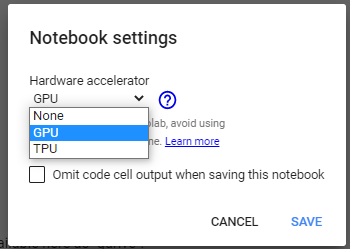

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


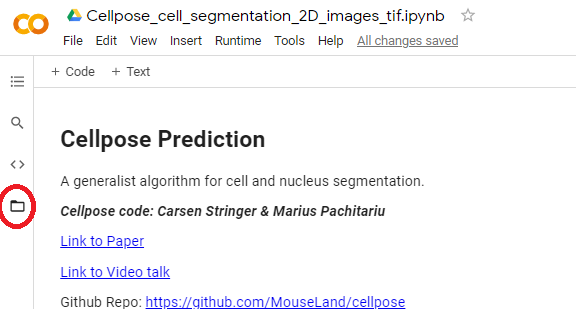

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

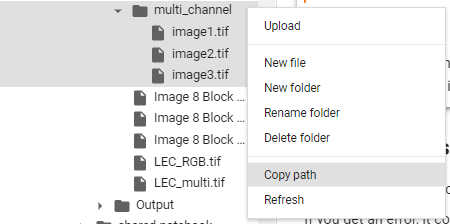

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-wmlwvy5w
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-wmlwvy5w
  Resolved https://www.github.com/mouseland/cellpose.git to commit c69c4ae75d7d08a3677039be3334327f04cc4f5d
  Preparing metadata (setup.py) ... done


Check GPU and instantiate model - will download weights.

In [ ]:
import numpy as np
from cellpose import models, core, io, plot, utils
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)
current_model = 'cpsam'

creating new log file
[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.1.2.dev67+gc69c4ae75 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-16 01:01:23,902 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-16 01:01:23,903 [io INFO] 
cellpose version: 	4.1.2.dev67+gc69c4ae75 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-16 01:01:24,305 [core INFO] ** TORCH CUDA version installed and working. **
2026-05-16 01:01:24,306 [core INFO] ** TORCH CUDA version installed and working. **
2026-05-16 01:01:24,308 [core INFO] >>>> using GPU (CUDA)
2026-05-16 01:01:26,748 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:12<00:00, 95.4MB/s]


Input directory with your images:

In [ ]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/mancha/sampleData"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".jpg"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

18 images in folder:
Croc1_II2.jpg
Croc1_II3.jpg
Croc1_II4.jpg
Croc1_II5.jpg
Croc1_II6.jpg
Croc1_II7.jpg
Croc1_II8.jpg
Croc1_II9.jpg
Croc1_II10.jpg
Croc1_II11.jpg
Croc1_II12.jpg
Croc1_II14.jpg
Croc1_II16.jpg
Croc1_II18.jpg
Croc1_II19.jpg
Croc1_II21.jpg
Croc1_II22.jpg
Croc1_II23.jpg


## Parameter Tuning on One Image

Use this section to tune segmentation parameters on a random image before running the full folder. Adjust the sliders, re-run the cell, and inspect results to find the best values for your data.

* **flow_threshold** (default 0.4): maximum allowed flow error for each mask.
    * Increase if too few masks are returned (set to 0.0 to turn off completely).
    * Decrease if too many ill-shaped masks are returned.

* **cellprob_threshold** (default 0.0): probability threshold for detected objects.
    * Decrease if masks are too small or missing.
    * Increase if too many masks from dim / dull areas.

* **diameter** (default 0 = auto-estimate): expected cell diameter in pixels. Cellpose rescales the image so cells appear ~30 px to the model.
    * Set to 0 to let Cellpose auto-estimate the diameter.
    * If your cells are ~60 px across, set diameter=60; if ~15 px, set diameter=15.

* **tile_norm_blocksize** (default 0): block size for tile-based normalization.
    * Set to 100-200 px for images with very inhomogeneous brightness.
    * 0 means the whole image is normalized together.

* **pretrained_model**: choose the model variant.  Changing this re-downloads weights the first time a new model is selected.


In [ ]:
import random

# check to re-randomize; uncheck to keep the same image across runs
rerandomize = True # @param {type:"boolean"}
# manual override: set >= 0 to pick a specific image index
manual_index = -1 # @param {type:"integer"}

if 'test_file_idx' not in globals() or rerandomize:
    test_file_idx = random.randint(0, len(files) - 1)

if 0 <= manual_index < len(files):
    test_file_idx = manual_index

img = io.imread(files[test_file_idx])
print('Selected: ' + files[test_file_idx].name
      + '  (index ' + str(test_file_idx) + ', image '
      + str(test_file_idx+1) + '/' + str(len(files)) + ')')
print('Image shape:', img.shape,
      ' (channel dimension is last with', img.shape[-1], 'channels)')

Selected: Croc1_II19.jpg  (index 14, image 15/18)
Image shape: (1536, 2048, 3)  (channel dimension is last with 3 channels)


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluorescent image with multiple stains, choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`.

In [ ]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]

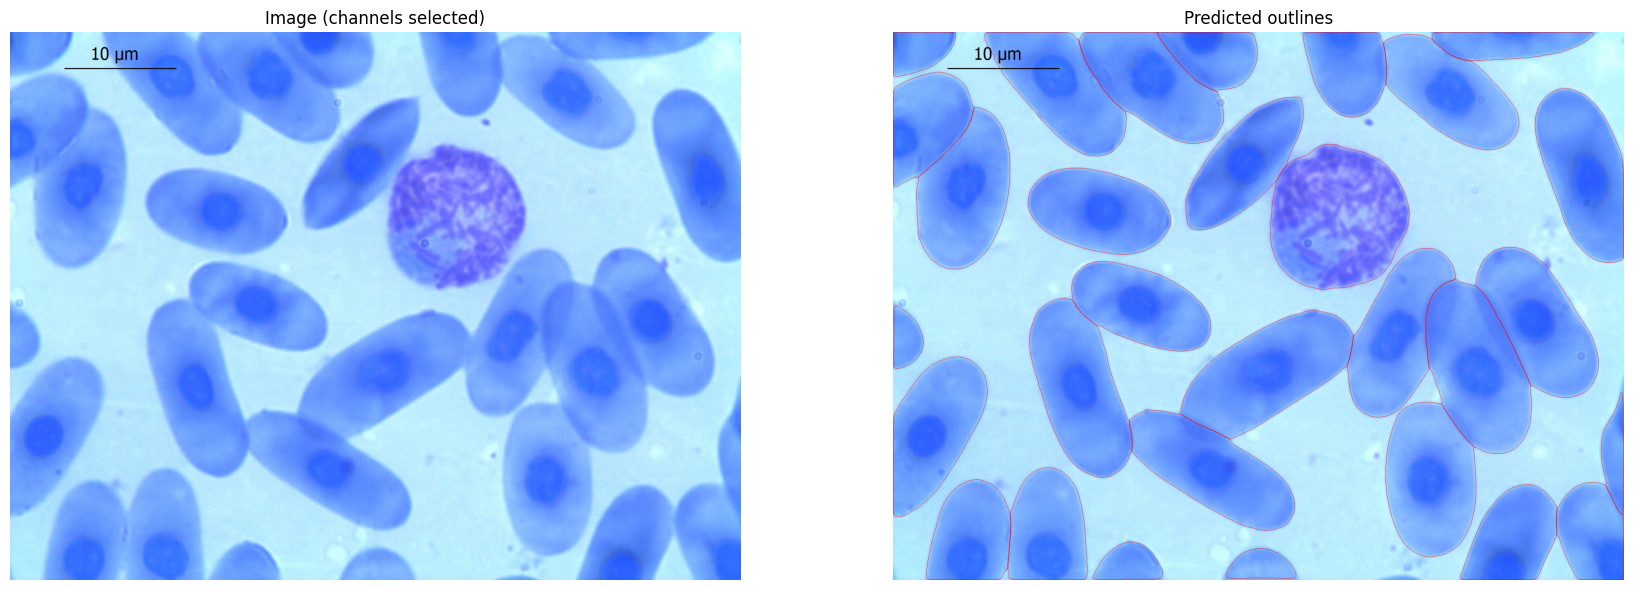

Masks found: 30
Parameters: flow_threshold=0.4, cellprob_threshold=0.0, diameter=100, tile_norm_blocksize=0, model=cpsam


In [ ]:
import numpy as np
from cellpose import models, core, io, plot, utils
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

# --- model selection ---
pretrained_model = 'cpsam' # @param ['cpsam', 'cyto', 'cyto2', 'cyto3', 'nuclei']
if 'current_model' not in globals() or current_model != pretrained_model:
    print('Loading model:', pretrained_model, '...')
    current_model = pretrained_model
    model = models.CellposeModel(gpu=True, pretrained_model=pretrained_model)

# --- segmentation parameters ---
flow_threshold = 0.4 # @param {type:"slider", min:0.0, max:1.0, step:0.05}
cellprob_threshold = 0.0 # @param {type:"slider", min:-6.0, max:6.0, step:0.1}
diameter = 100 # @param {type:"slider", min:0, max:200, step:5}
tile_norm_blocksize = 0 # @param {type:"slider", min:0, max:500, step:25}

# --- channel processing ---
selected_channels = []
for c in [first_channel, second_channel, third_channel]:
    if c == 'None':
        continue
    if int(c) >= img.shape[-1]:
        assert False, 'invalid channel index, must be less than number of channels'
    selected_channels.append(int(c))

img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]

# --- run segmentation ---
diameter_val = None if diameter == 0 else diameter
masks, flows, styles = model.eval(
    img_selected_channels,
    batch_size=32,
    flow_threshold=flow_threshold,
    cellprob_threshold=cellprob_threshold,
    diameter=diameter_val,
    normalize={'tile_norm_blocksize': tile_norm_blocksize},
)

# --- display: raw image + segmentation outlines side-by-side ---
fig = plt.figure(figsize=(18, 6))

# panel 1: selected channel(s)
plt.subplot(1, 2, 1)
img_show = img_selected_channels.astype(np.float32)
if img_show.shape[-1] == 1:
    img_show_to_plot = img_show[:, :, 0]
    # For grayscale with cmap='gray', imshow can handle [0-255] floats or [0-1] floats
    plt.imshow(img_show_to_plot, cmap='gray')
elif img_show.shape[-1] == 2:
    c0 = img_show[:, :, 0]
    c1 = img_show[:, :, 1]
    img_show_to_plot = np.stack([c0, c1, np.zeros_like(c0)], axis=-1)
    # Normalize to [0,1] for RGB float display
    img_show_to_plot /= 255.0
    plt.imshow(img_show_to_plot)
elif img_show.shape[-1] >= 3:
    img_show_to_plot = img_show[:, :, :3] # Take first 3 channels for RGB display
    # Normalize to [0,1] for RGB float display
    img_show_to_plot /= 255.0
    plt.imshow(img_show_to_plot)

plt.title('Image (channels selected)')
plt.axis('off')

# panel 2: predicted outlines on image
plt.subplot(1, 2, 2)
img_disp = img_selected_channels.astype(np.float32).copy()
if img_disp.ndim == 2 or img_disp.shape[-1] == 1:
    if img_disp.ndim == 3:
        img_disp = img_disp[:, :, 0]
    img_disp = np.stack([img_disp, img_disp, img_disp], axis=-1)
elif img_disp.shape[-1] >= 3:
    img_disp = img_disp[:, :, :3]
elif img_disp.shape[-1] == 2:
    c0 = img_disp[:, :, 0]
    c1 = img_disp[:, :, 1]
    img_disp = np.stack([c0, c1, np.zeros_like(c0)], axis=-1)
img_disp = img_disp / max(img_disp.max(), 1e-8)

outlines = utils.masks_to_outlines(masks)
outY, outX = np.nonzero(outlines)
img_disp[outY, outX] = [1, 0, 0]  # red outlines
plt.imshow(img_disp)
plt.title('Predicted outlines')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Masks found:', masks.max())
d_label = 'auto' if diameter == 0 else str(diameter)
print('Parameters: flow_threshold=' + str(flow_threshold)
      + ', cellprob_threshold=' + str(cellprob_threshold)
      + ', diameter=' + d_label
      + ', tile_norm_blocksize=' + str(tile_norm_blocksize)
      + ', model=' + pretrained_model)

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [ ]:
masks_ext = '.png' if image_ext == '.png' else '.tif'
diameter_val = None if diameter == 0 else diameter
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        diameter=diameter_val,
        normalize={'tile_norm_blocksize': tile_norm_blocksize})
    io.imsave(dir / (f.stem + '_masks' + masks_ext), masks)

100%|██████████| 18/18 [03:32<00:00, 11.83s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print('loading images')
imgs = [io.imread(files[i]) for i in trange(len(files))]

diameter_val = None if diameter == 0 else diameter

print('running cellpose-SAM')
masks, flows, styles = model.eval(imgs, batch_size=32,
    flow_threshold=flow_threshold,
    cellprob_threshold=cellprob_threshold,
    diameter=diameter_val,
    normalize={'tile_norm_blocksize': tile_norm_blocksize})

print('saving masks')
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + '_masks' + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
    io.save_rois(masks0, f)